In [95]:
import healpy as hp
from scripts.utils import plot_cl_alm, load_data
from scripts.config import SimConfig

import matplotlib.pyplot as plt
from pixell import enmap, lensing, curvedsky, reproject
import numpy as np
# from scripts.utils import get_radii
from ksw import Cosmology, Data
import camb
from ksw.radial_functional import radial_func
from tqdm.auto import tqdm

from scipy.interpolate import CubicSpline
from joblib import Parallel, delayed

import os
import h5py
import seaborn as sns

In [96]:
def print_dir(dir_path, ext='.hdf5', print_keys=[], plot_keys=[], plot_sigmas=True):
    # Get a list of all files in the directory
    files = os.listdir(dir_path)

    # Filter the list to include only HDF5 files
    hdf5_files = [file for file in files if file.endswith(ext)]

    to_plot = plot_keys != []

    if to_plot:
        fig, axs = plt.subplots(len(plot_keys), figsize=(10, 5*len(plot_keys)))
        axs = np.atleast_1d(axs)

    for hdf5_file in hdf5_files:
        # Open the file
        with h5py.File(os.path.join(dir_path, hdf5_file), 'r') as f:
            # Print the file name
            print('File:', hdf5_file, 'Keys:', list(f.keys()))
            for key in print_keys:
                print('\t\t\t', key, ':', np.array(f[key]))

            if to_plot:
                for i, key in enumerate(plot_keys):
                    data = np.array(f[key])
                    use_kde = True
                    if key == 'fnls':
                        data = data.reshape(-1)
                        use_kde = False
                        

                    sns.histplot(data, ax=axs[i], kde=use_kde, label=hdf5_file, stat="density")
                    axs[i].set_title(key)

                    if plot_sigmas and key == 'estimates':
                        fisher = np.array(f['fisher'])
                        mean = 0 # by design
                        fisher_inv = 1/fisher # np.linalg.inv(fisher)
                        std_dev = np.sqrt(np.diag(fisher_inv))

                        for sigma in range(1, 4):
                            axs[i].axvline(mean - sigma*std_dev, color='red', linestyle='dashed', linewidth=1)
                            axs[i].axvline(mean + sigma*std_dev, color='red', linestyle='dashed', linewidth=1)

                


    if to_plot:
        for ax in axs:
            ax.legend()
        # plt.xlabel(r'$(f_{nl}^{pred,ksw}-f_{nl}^{true})/var$')
        plt.show()

In [97]:
import os
import h5py

# Directory containing the HDF5 files
dir_path = 'data/alm_cache'
print_dir(dir_path)

File: 512_nn_T_100_5.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_2.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_8.alms.hdf5 Keys: ['alm', 'almng']
File: 128_nn_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 128_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 2048_T_100.alms.hdf5 Keys: ['alm', 'settings']
File: 512_nn_T_100_1.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 1024_nn_T_100.alms.hdf5 Keys: ['alm', 'settings']
File: 512_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 512_nn_T_100_3.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_4.alms.hdf5 Keys: ['alm', 'almng']
File: 256_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 2048_nn_T_100.alms.hdf5 Keys: ['alm', 'settings']
File: 1024_T_100.alms.hdf5 Keys: ['alm', 'settings']
File: 512_nn_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 512_nn_T_100_6.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_10.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_7.alms.

File: 128_T_100x10x10_fnl-1000-1000.hdf5 Keys: ['errors', 'errors_var', 'estimates', 'fisher', 'fisher_iso', 'fnls', 'patches', 'settings']
			 errors_var : [6.47302782e+11]
			 fisher : [0.00367666]
			 fisher_iso : [0.00366866]
File: 128_nn_T_100x10x10_fnl-1000-1000.hdf5 Keys: ['errors', 'errors_var', 'estimates', 'fisher', 'fisher_iso', 'fnls', 'patches', 'settings']
			 errors_var : [6.7668543e+09]
			 fisher : [0.32911783]
			 fisher_iso : [0.00366866]


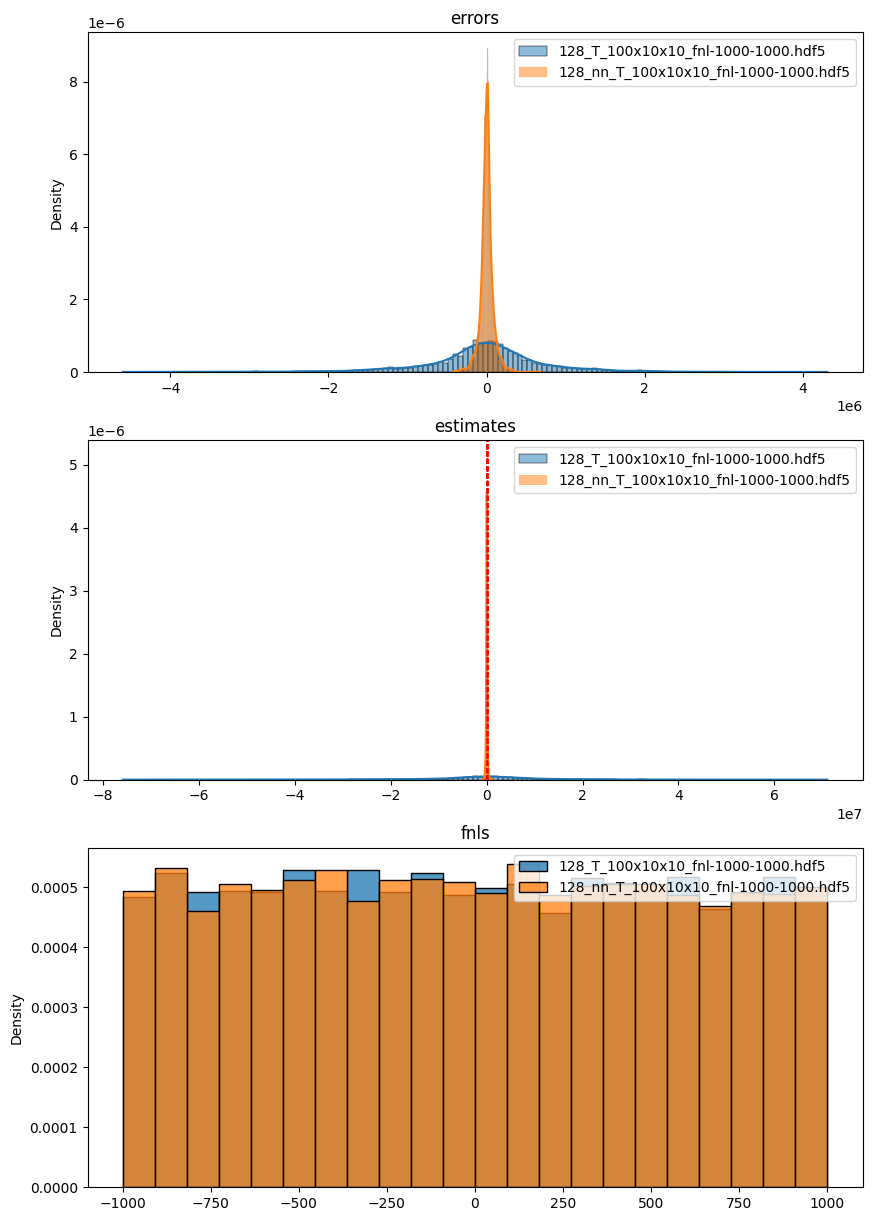

In [98]:
dir_path = 'data/lensed'
print_dir(dir_path, print_keys=['errors_var', 'fisher', 'fisher_iso'], plot_keys=['errors', 'estimates', 'fnls'])

File: 128_nn_T_100x10x10_fnl-10-10.hdf5 Keys: ['errors', 'errors_var', 'estimates', 'fisher', 'fisher_iso', 'fnls', 'patches', 'settings']
			 errors_var : [6.84251202e+09]
			 fisher : [0.32298813]
			 fisher_iso : [0.00366866]


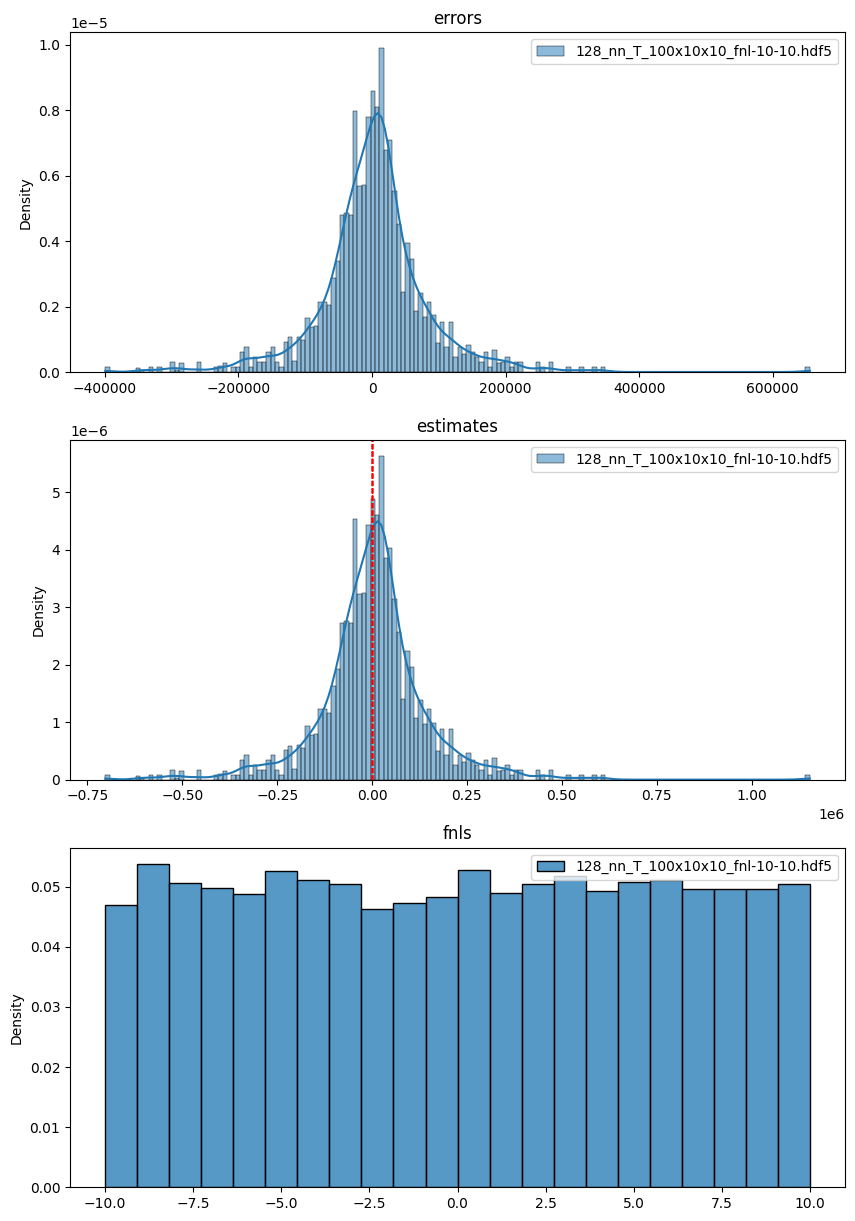

In [99]:
dir_path = 'data/unlensed'
print_dir(dir_path, print_keys=['errors_var', 'fisher', 'fisher_iso'], plot_keys=['errors', 'estimates', 'fnls'])